Epoch 500: Loss = 3.52623e-02
Epoch 1000: Loss = 2.87944e-03
Epoch 1500: Loss = 9.03868e-04
Epoch 2000: Loss = 5.26942e-04
Epoch 2500: Loss = 3.35746e-04
Epoch 3000: Loss = 2.49228e-04
Epoch 3500: Loss = 1.94720e-04
Epoch 4000: Loss = 1.53572e-04
Epoch 4500: Loss = 1.25366e-04
Epoch 5000: Loss = 9.44405e-05
Epoch 5500: Loss = 7.39526e-05
Epoch 6000: Loss = 5.86902e-05
Epoch 6500: Loss = 4.84163e-05
Epoch 7000: Loss = 4.13610e-05
Epoch 7500: Loss = 4.02498e-05
Epoch 8000: Loss = 1.29049e-04
Epoch 8500: Loss = 2.31030e-04
Epoch 9000: Loss = 3.04580e-05
Epoch 9500: Loss = 2.61843e-05
Epoch 10000: Loss = 2.41432e-05


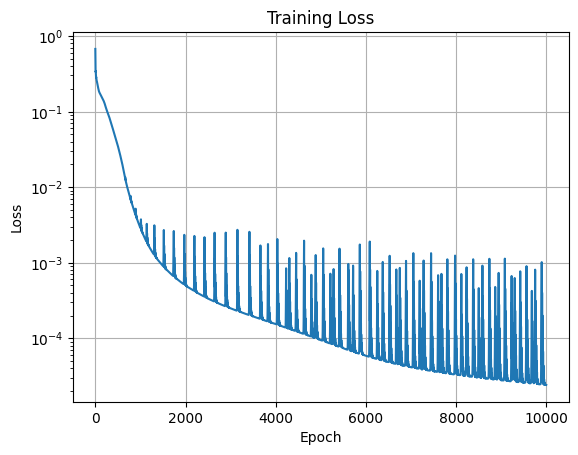

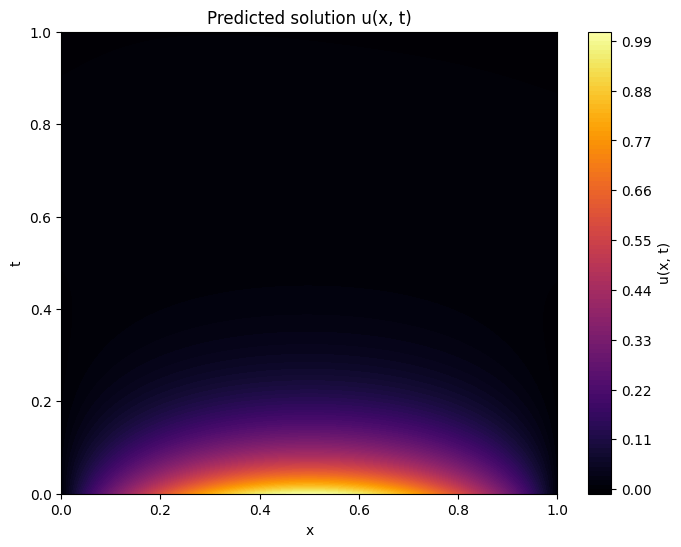

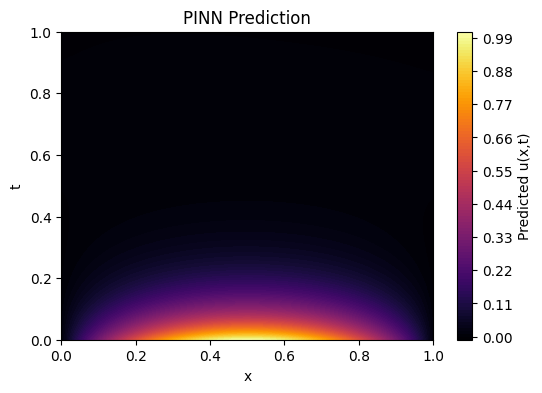

ValueError: cannot reshape array of size 100000000 into shape (100,100)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from src.pinn_model import PINN
from src.data_generator import (
    generate_collocation_points,
    generate_boundary_points,
    generate_initial_condition
)

# ----- Settings -----
N_colloc = 10000
N_bound = 2000
N_init = 2000
learning_rate = 0.001
epochs = 10000

# Initial condition function u(x, 0) = sin(pi x)
u0_fn = lambda x: np.sin(np.pi * x)

# ----- Generate training data -----
X_colloc = tf.convert_to_tensor(generate_collocation_points(N_colloc), dtype=tf.float32)
X_colloc_var = tf.Variable(X_colloc)
X_bound = tf.convert_to_tensor(generate_boundary_points(N_bound), dtype=tf.float32)
X_init_np, u_init_np = generate_initial_condition(N_init, u0_fn=u0_fn)
X_init = tf.convert_to_tensor(X_init_np, dtype=tf.float32)
u_init = tf.convert_to_tensor(u_init_np, dtype=tf.float32)

# ----- Model -----
model = PINN()

# ----- Optimizer -----
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss_history = []

# ----- Training Step -----
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        # Physics loss
        f = model.compute_pde_residual(X_colloc_var)
        loss_f = tf.reduce_mean(tf.square(f))

        # Boundary loss
        u_bound = model(X_bound)
        loss_b = tf.reduce_mean(tf.square(u_bound))  # u=0 at boundaries

        # Initial condition loss
        u_pred_init = model(X_init)
        loss_i = tf.reduce_mean(tf.square(u_pred_init - u_init))

        total_loss = loss_f + loss_b + loss_i

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss

# ----- Training Loop -----
for epoch in range(1, epochs + 1):
    loss = train_step()
    loss_history.append(loss.numpy())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.5e}")

# ----- Plot Loss History -----
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


x_vals = np.linspace(0, 1, 100)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)
XT = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
XT_tensor = tf.convert_to_tensor(XT, dtype=tf.float32)


u_pred = model(XT_tensor)
U = u_pred.numpy().reshape(100, 100)



XT_tensor shape: (10000, 2)
u_pred shape: (10000, 1)
u_pred shape: (10000, 1)


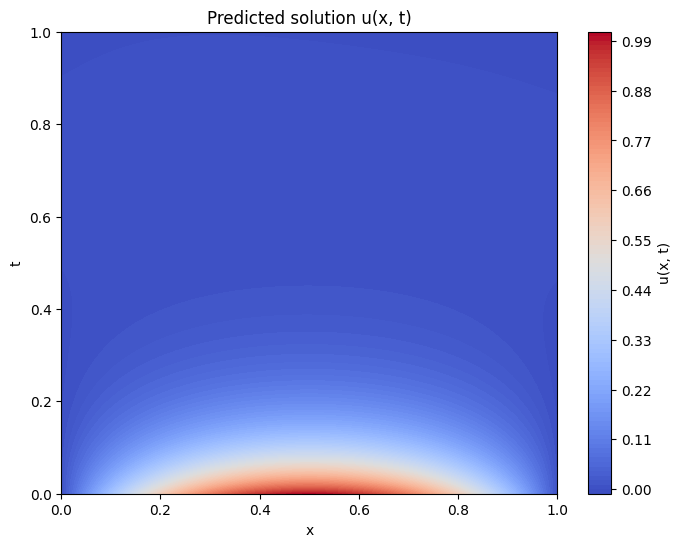

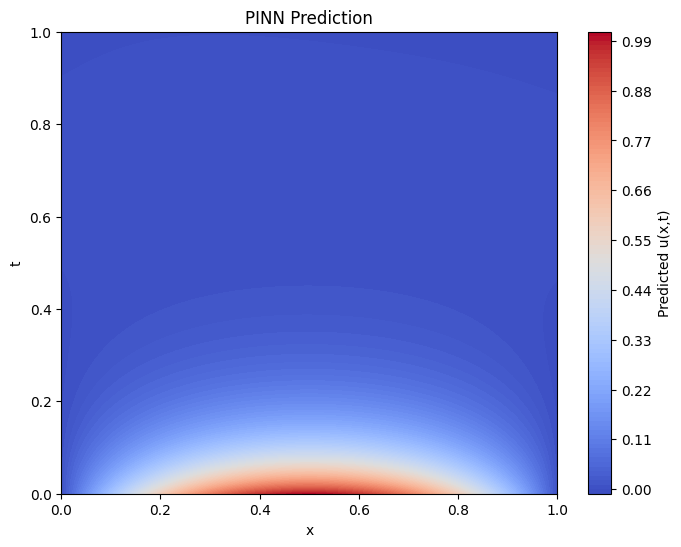

u_exact shape: (10000,)
error shape: (10000,)


In [14]:
print("XT_tensor shape:", XT_tensor.shape)
print("u_pred shape:", u_pred.shape)

print("u_pred shape:", u_pred.shape)



import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.contourf(X, T, U, 100, cmap='coolwarm')
plt.colorbar(label='u(x, t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted solution u(x, t)')
plt.show()


u_pred_np = u_pred.numpy().flatten()           # shape (10000,)
u_exact = np.sin(np.pi * XT[:, 0]) * np.exp(-np.pi**2 * XT[:, 1])  # already shape (10000,)
error = np.abs(u_pred_np - u_exact) 

U_pred = u_pred.numpy().reshape(100, 100)
plt.figure(figsize=(8, 6))
plt.contourf(X, T, U_pred, 100, cmap='coolwarm')
plt.colorbar(label='Predicted u(x,t)')
plt.title('PINN Prediction')
plt.xlabel('x')
plt.ylabel('t')
plt.show()

print("u_exact shape:", u_exact.shape)
print("error shape:", error.shape)

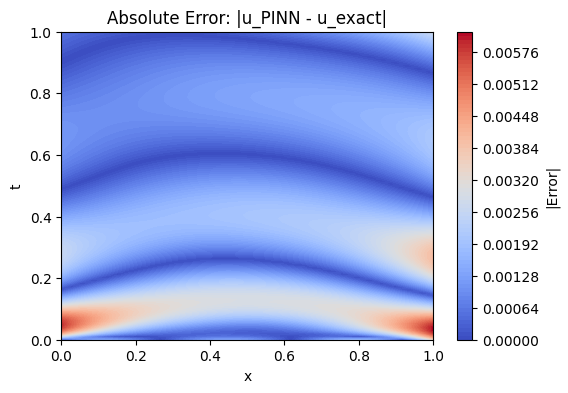

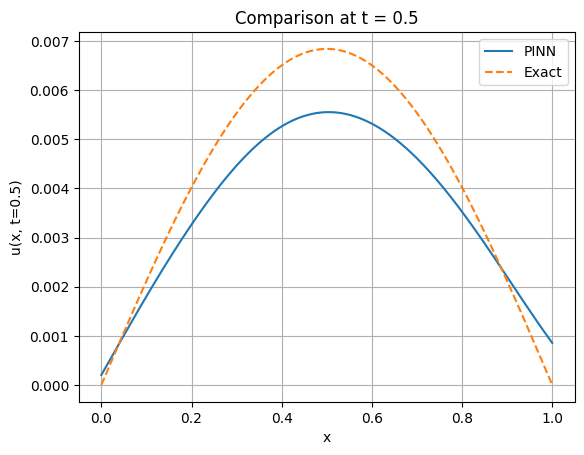

In [15]:

Error = error.reshape(100, 100)
plt.figure(figsize=(6, 4))
plt.contourf(X, T, Error, 100, cmap='coolwarm')
plt.colorbar(label='|Error|')
plt.title('Absolute Error: |u_PINN - u_exact|')
plt.xlabel('x')
plt.ylabel('t')
plt.show()


mid_idx = 50  # index for t ≈ 0.5
plt.plot(x_vals, U_pred[mid_idx, :], label="PINN")
plt.plot(x_vals, np.sin(np.pi * x_vals) * np.exp(-np.pi**2 * t_vals[mid_idx]), label="Exact", linestyle='dashed')
plt.xlabel("x")
plt.ylabel("u(x, t=0.5)")
plt.legend()
plt.title("Comparison at t = 0.5")
plt.grid(True)
plt.show()
